In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [4]:
!pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 68 kB 1.1 MB/s  eta 0:00:01


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

100%|██████████| 172k/172k [00:00<00:00, 9.63MB/s]

Extracting files...
Path to dataset files: /home/d12753be-8f30-4c2a-b991-36a83041f79f/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/home/d12753be-8f30-4c2a-b991-36a83041f79f/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look at the data
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check for missing values and data types
print(df.info())
print("\n")

# Check churn rate
print("Churn Rate:")
print(df['Churn'].value_counts())
print("\n")
print(df['Churn'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Fix TotalCharges - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls that created
print("Null values in TotalCharges:", df['TotalCharges'].isnull().sum())

# Basic stats on our key numeric columns
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


Null values in TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


Matplotlib is building the font cache; this may take a moment.


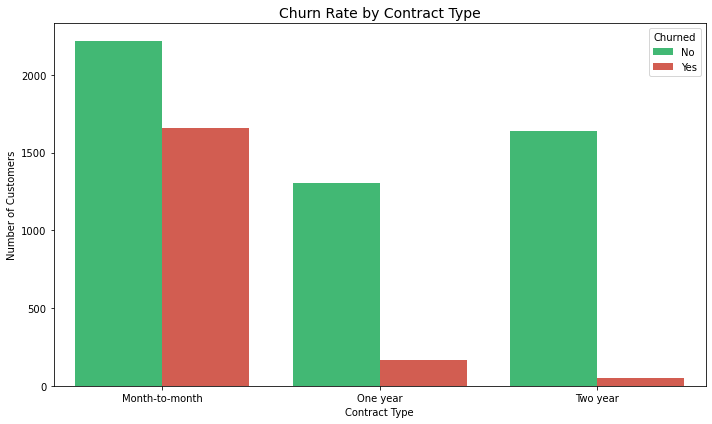

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the 11 null rows
df = df.dropna(subset=['TotalCharges'])

# First visualization - churn by contract type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned')
plt.tight_layout()
plt.show()


In [7]:
# Churn by tenure
sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Tenure by Churn Status')
axes[0].set_xlabel('Churned')
axes[0].set_ylabel('Months as Customer')

# Churn by monthly charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status')
axes[1].set_xlabel('Churned')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

NameError: name 'axes' is not defined

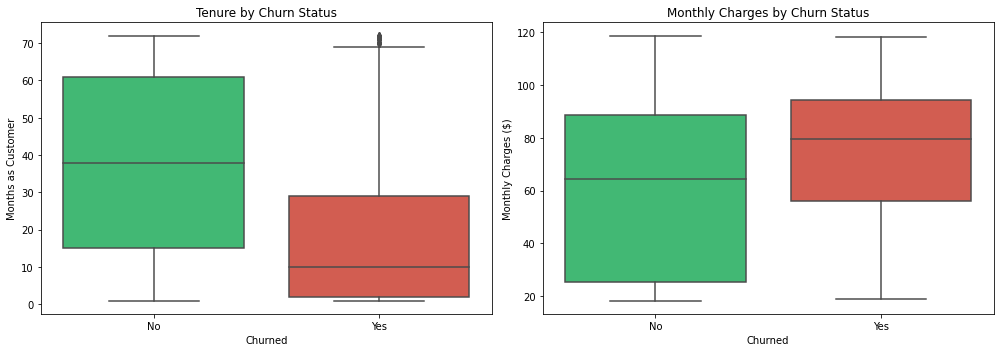

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Tenure by Churn Status')
axes[0].set_xlabel('Churned')
axes[0].set_ylabel('Months as Customer')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status')
axes[1].set_xlabel('Churned')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

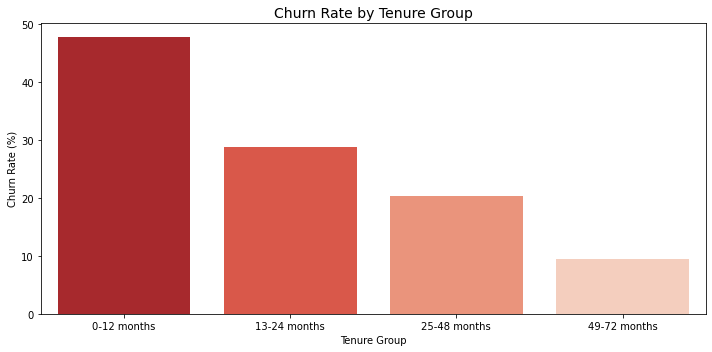

In [9]:
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72], 
                             labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])

# Churn rate by tenure group
churn_by_tenure = df.groupby('tenure_group')['Churn'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=churn_by_tenure, x='tenure_group', y='Churn', palette='Reds_r')
plt.title('Churn Rate by Tenure Group', fontsize=14)
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to keep our original data clean
df_model = df.copy()

# Drop customerID - not useful for prediction
df_model = df_model.drop('customerID', axis=1)

# Convert Churn to 0/1
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Convert all other text columns to numbers
le = LabelEncoder()
cat_columns = df_model.select_dtypes(include='object').columns

for col in cat_columns:
    df_model[col] = le.fit_transform(df_model[col])

# Check it worked
print(df_model.head())
print("\nChurn values:", df_model['Churn'].unique())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             0  ...   
2              0                0               2             2  ...   
3              1                0               2             0  ...   
4              0                1               0             0  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0            0            0                0         0          

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Drop tenure_group - it's text and we already have tenure as a number
df_model = df_model.drop('tenure_group', axis=1)

# Split into features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# See how well it did
print("Model Performance:")
print(classification_report(y_test, y_pred))


Model Performance:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



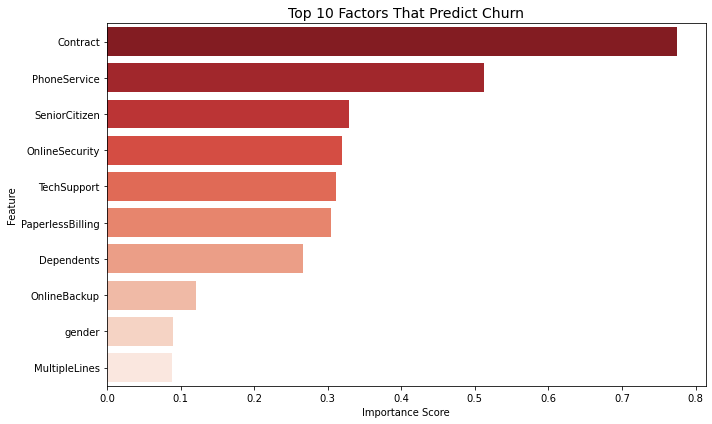

             Feature  Importance
14          Contract    0.774863
5       PhoneService    0.512978
1      SeniorCitizen    0.328363
8     OnlineSecurity    0.319666
11       TechSupport    0.310970
15  PaperlessBilling    0.304866
3         Dependents    0.267033
9       OnlineBackup    0.120818
0             gender    0.089314
6      MultipleLines    0.087730


In [13]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', palette='Reds_r')
plt.title('Top 10 Factors That Predict Churn', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

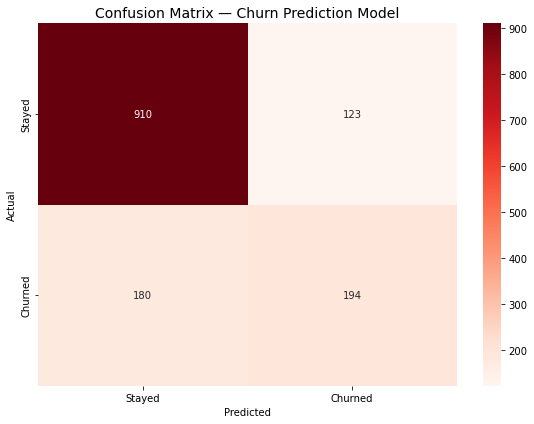

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — Churn Prediction Model', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()